In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle

In [49]:

# helper to format annotations "mean ± se" (empty string for NaNs)
def make_annot(mean_df, se_df, fmt_mean="{:.2f}", fmt_se="{:.2f}"):
    annot = mean_df.copy().astype(object)
    for i in mean_df.index:
        for j in mean_df.columns:
            m = mean_df.at[i, j]
            s = se_df.at[i, j]
            if pd.isna(m):
                annot.at[i, j] = ""
            else:
                annot.at[i, j] = f"{fmt_mean.format(m)}±\n{fmt_se.format(s if not pd.isna(s) else 0.0)}"
    return annot

def highlight_row_mins(pivot, axis, cols):
    cols_present = [c for c in cols if c in pivot.columns]
    for row in [r for r in pivot.index if r in range(1,8)]:
        if row not in pivot.index:
            continue
        row_vals = pivot.loc[row, cols_present]
        if row_vals.isna().all():
            continue
        # find the column with minimum value for this row (among cols_present)
        try:
            min_col = row_vals.astype(float).idxmin()
        except Exception:
            continue
        if pd.isna(min_col):
            continue
        # compute 0-based positions for rectangle
        x_pos = list(pivot.columns).index(min_col)
        y_pos = list(pivot.index).index(row)
        # add rectangle (non-filled red box)
        rect = Rectangle((x_pos, y_pos), 1, 1, fill=False, edgecolor='green', lw=2, zorder=10)
        axis.add_patch(rect)

In [51]:
interval = 5
mapping = {161 : 1, 172 : 2, 182 : 3, 196 : 4, 207 : 5, 223 : 6, 232 : 7}
mapping2 = {161 : 1, 172 : 2, 182 : 3, 196 : 4, 207 : 5, 223 : 6, 232 : 7, "avg": 8}

In [ ]:
df = pd.read_csv("../../output/task2_5_30_1/0_60_360/model_evaluation/evaluation_output_constrained.txt")
df.head()

,Model,Config,Time_To_Train,Test,Val,Interval,MSE,MAE,Lag1_Autocorr,N_eff_AR1,ADF_pvalue,LjungBox_pvalue,MSE_HAC_SE,MSE_CI_HAC_low,MSE_CI_HAC_high,ref_MSE,True_Peak,Peak,Peak_Diff,Peak_Diff_percent
0,LSTM,v4,0:01:38,161,172,5,220.8754,11.0486,0.9995,0.4,0.6712,0,21.2099,179.3040,262.4468,245.7067,89.998,108.948,18.950,21.06
1,xLSTM,v4,0:09:52,161,172,5,208.3402,11.7419,0.9990,0.9,0.6702,0,19.9269,169.2835,247.3970,230.9323,89.998,114.790,24.792,27.55
2,LSTM,v4,0:01:47,161,182,5,183.2749,10.2222,0.9995,0.5,0.6724,0,16.4957,150.9434,215.6064,207.3661,89.998,101.957,11.959,13.29
3,xLSTM,v4,0:15:33,161,182,5,170.2152,10.1954,0.9977,2.0,0.5927,0,14.2469,142.2914,198.1391,194.6543,89.998,107.821,17.823,19.80
4,LSTM,v4,0:01:23,161,196,5,221.5617,10.9840,0.9994,0.5,0.7157,0,19.6715,183.0057,260.1178,245.9683,89.998,108.139,18.141,20.16


In [ ]:
df_xlstm = df[
    (df['Model'] == "xLSTM") &
    (df['Config'] == "v4") & 
    (df['Interval'] == interval)
]

In [22]:
df_plot = df_xlstm[['Test', 'Val', 'MSE', 'MSE_HAC_SE']]

In [23]:
mapping = {161 : 1, 172 : 2, 182 : 3, 196 : 4, 207 : 5, 223 : 6, 232 : 7}
df_plot['x'] = df_plot['Test'].apply(lambda x : mapping[x])
df_plot['y'] = df_plot['Val'].apply(lambda x : mapping[x])

/var/folders/9b/f10dy2654w79wqw49pdgt37c0000gp/T/ipykernel_71266/3069920048.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot['x'] = df_plot['Test'].apply(lambda x : mapping[x])
/var/folders/9b/f10dy2654w79wqw49pdgt37c0000gp/T/ipykernel_71266/3069920048.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot['y'] = df_plot['Val'].apply(lambda x : mapping[x])


In [25]:
df_plot = df_plot[['x', 'y', 'MSE', 'MSE_HAC_SE']]

In [39]:
pivot_mse = df_plot.pivot(index='x', columns='y', values='MSE').reindex(index=range(1,8), columns=range(1,8))
pivot_se = df_plot.pivot(index='x', columns='y', values='MSE_HAC_SE').reindex(index=range(1,8), columns=range(1,8))
pivot_mse

y,1,2,3,4,5,6,7
x,,,,,,,
1,NaN,208.3402,170.2152,207.6681,198.2384,178.7844,171.6670
2,183.6857,NaN,198.1815,192.5186,121.5865,266.4907,203.5919
3,182.5873,167.7833,NaN,167.5429,205.0103,217.1731,152.3179
4,343.7504,370.0856,288.9810,NaN,319.0724,316.5186,308.6750
5,163.9595,132.8694,203.6269,153.9899,NaN,172.0777,163.2562
6,266.1530,264.1714,269.1804,263.3628,251.8260,NaN,307.1132
7,104.3963,135.2127,88.4727,109.9063,103.7466,110.4772,NaN


<Axes: xlabel='y', ylabel='x'>

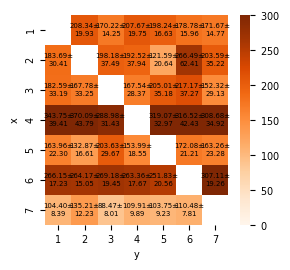

In [ ]:
plt.rcParams.update({'font.size': 7,
                     'axes.formatter.limits': (-3, 6),
                     'axes.formatter.use_mathtext': True})


from pathlib import Path
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(6.5, 6))
gs = gridspec.GridSpec(2, 2)

subplot_idx = ["(a)", "(b)", "(c)", "(d)"]
cmap = "Oranges"

ax = plt.subplot(gs[0])

# sns.heatmap(pivot_mse, ax=ax, cmap='Greens', cbar=False,
#             annot=False, fmt='', mask=pivot_mse.isna(), vmin=0, vmax=300,
#             linewidths=0.5, linecolor='w')

annot = make_annot(pivot_mse, pivot_se)

sns.heatmap(pivot_mse, annot=annot, fmt='', cmap=cmap, ax=ax, annot_kws={'fontsize': 5, 'color': 'k'}, vmin=0, vmax=300)

highlight_row_mins(pivot_mse, ax, pivot_mse.columns.tolist())
            # Labels and ticks
order = list(range(1, 9))
inv_map = {v: k for k, v in mapping2.items()}
labelx = [inv_map[i] for i in order]

# for axis in ax:
ax.tick_params(axis='both', which='major', labelsize=7, length=3)
ax.set_xticklabels(labelx, rotation=0, ha='center', fontsize=7)
ax.set_yticklabels(labelx[:7], rotation=0, fontsize=7)

if idx in [0, 2]:
    ax.set_ylabel('Test (Julday)', fontsize=7, fontweight='bold')
else:
    ax.set_ylabel('', fontsize=7, fontweight='bold')

if idx in [2, 3]:
    ax.set_xlabel('Validation (Julday)', fontsize=7, fontweight='bold')
else:
    ax.set_xlabel('', fontsize=7, fontweight='bold')

    
ax.set_ylim(7, 0)
ax.set_xlim(0, 8)
ax.axvline(x=7, color='k', linewidth=1.5, zorder=20)
ax.set_title(f'{subplot_idx[idx]} {model}, Time shift: {time_shift}-min', fontsize=7, fontweight="bold", loc="left")

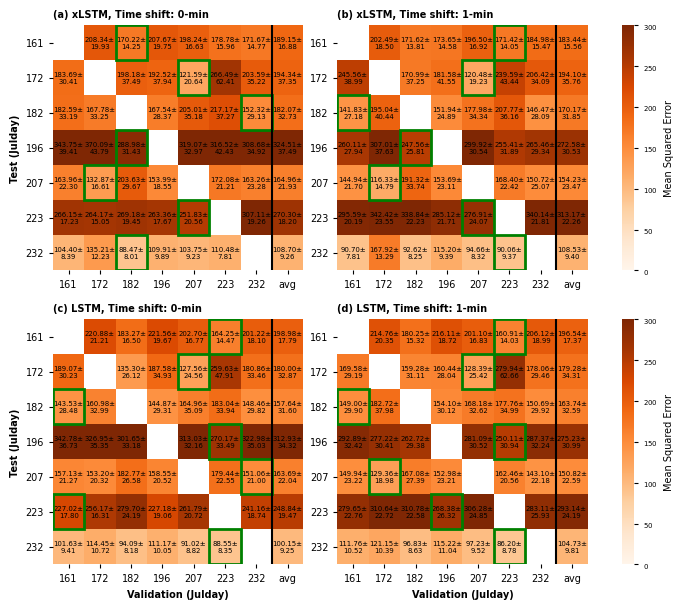

In [71]:
fig = plt.figure(figsize=(7.5, 7))
gs = gridspec.GridSpec(2, 3, width_ratios=[10, 10, 0.5])

subplot_idx = ["(a)", "(b)", "(c)", "(d)"]
cmap = "Oranges"
ax_list = {0: plt.subplot(gs[0, 0]), 
           1: plt.subplot(gs[0, 1]), 
           2: plt.subplot(gs[1, 0]), 
           3: plt.subplot(gs[1, 1]),
           
           4: plt.subplot(gs[0, 2]),
           5: plt.subplot(gs[1, 2])}

idx = 0
for model in ['xLSTM', 'LSTM']:
    for time_shift in ["0", "1"]:# ["0", "average", "1"]:
        # for metric in ["MSE"]: #["MSE", "Peak_Diff"]: # Column Name
            
        ax = ax_list.get(idx)
        
        result_dir = "../../output"
        result_dirs = [f"{result_dir}/task2_5_30_{i}" for i in [1]]
        main_df = None
        for result_dir in result_dirs:
            df = pd.read_csv(f"{result_dir}/{time_shift}_60_360/model_evaluation/evaluation_output_constrained.txt", index_col=False)
            # display(len(df))
            df.drop_duplicates(subset=["Model", "Config", "Interval", "Test", "Val"], keep="last", inplace=True)
            # display(len(df))
            # display(df)
            df = df[(df['Config'] == "v4") & (df['Interval'] == interval) & (df['Model'] == model)].copy()
            df.reset_index(inplace=True, drop=True)
            # display(main_df)
            # display(df)
            if main_df is None:
                main_df = df.copy()
            else:
                main_df = pd.concat([main_df, df], axis=0, ignore_index=True)
        main_df['x'] = main_df['Test'].apply(lambda x : mapping[x])
        main_df['y'] = main_df['Val'].apply(lambda x : mapping[x])
        plot_df = main_df[['x', 'y', 'MSE', 'MSE_HAC_SE']]
        # Create pivot table with mean values
        pivot_mean = plot_df.pivot(index='x', columns='y', values='MSE')

        # Create pivot table with standard errors
        pivot_se = plot_df.pivot(index='x', columns='y', values='MSE_HAC_SE')

        avg_row = plot_df.groupby('x')["MSE"].mean()
        pivot_mean.loc[:,8] = avg_row

        pivot_se_avg = plot_df.groupby('x')['MSE_HAC_SE'].mean()
        pivot_se.loc[:,8] = pivot_se_avg

        annot = make_annot(pivot_mean, pivot_se)

        vmin, vmax = 0, 300
        metricl = 'Mean Squared Error'
        fs = 5

        if idx in [1]:
            sns.heatmap(pivot_mean, annot=annot, fmt='', cmap=cmap, ax=ax, annot_kws={'fontsize': fs, "color": "k"}, vmin=vmin, vmax=vmax, cbar_ax=ax_list.get(4))
            ax.collections[0].colorbar.ax.tick_params(labelsize=5, length=3)
            ax.collections[0].colorbar.set_label(label=metricl, size=7)
        elif idx in [3]:
            sns.heatmap(pivot_mean, annot=annot, fmt='', cmap=cmap, ax=ax, annot_kws={'fontsize': fs, "color": "k"}, vmin=vmin, vmax=vmax, cbar_ax=ax_list.get(5))
            ax.collections[0].colorbar.ax.tick_params(labelsize=5, length=3)
            ax.collections[0].colorbar.set_label(label=metricl, size=7)
        else:
            sns.heatmap(pivot_mean, annot=annot, fmt='', cmap=cmap, ax=ax, annot_kws={'fontsize': fs, "color": "k"}, vmin=vmin, vmax=vmax, cbar=False)

        highlight_row_mins(pivot_mean, ax, pivot_mean.columns.tolist())
        # Labels and ticks
        order = list(range(1, 9))
        inv_map = {v: k for k, v in mapping2.items()}
        labelx = [inv_map[i] for i in order]

        # for axis in ax:
        ax.tick_params(axis='both', which='major', labelsize=7, length=3)
        ax.set_xticklabels(labelx, rotation=0, ha='center', fontsize=7)
        ax.set_yticklabels(labelx[:7], rotation=0, fontsize=7)
        
        if idx in [0, 2]:
            ax.set_ylabel('Test (Julday)', fontsize=7, fontweight='bold')
        else:
            ax.set_ylabel('', fontsize=7, fontweight='bold')
        
        if idx in [2, 3]:
            ax.set_xlabel('Validation (Julday)', fontsize=7, fontweight='bold')
        else:
            ax.set_xlabel('', fontsize=7, fontweight='bold')
        
            
        ax.set_ylim(7, 0)
        ax.set_xlim(0, 8)
        ax.axvline(x=7, color='k', linewidth=1.5, zorder=20)
        ax.set_title(f'{subplot_idx[idx]} {model}, Time shift: {time_shift}-min', fontsize=7, fontweight="bold", loc="left")
        
        idx = idx + 1

In [73]:
df = pd.read_csv("../../output/task2_5_30_1/0_60_360/output_df/v4/5/xLSTM_t172_v207.csv")

In [75]:
from autocorr_metrics import analyze_predictions

output_dir = "../../output/task2_5_30_1/0_60_360/output_df/5/"
result = analyze_predictions(f"{output_dir}/LSTM_t172_v207.csv", label="LSTM t172_v207")
result["metrics"]["RMSE"]["ci_hac"]   # -> (8.91, 13.25)


===== Autocorrelation-corrected metrics: LSTM t172_v207 =====
n = 2340
Residual lag-1 autocorrelation: 0.9950
Effective sample size (AR1 approx): 5.9
ADF p-value (residual stationarity): 7.533e-05  -> stationary
Ljung-Box test on residuals:
         lb_stat  lb_pvalue
5   11073.115212        0.0
10  20076.184592        0.0
20  31207.611941        0.0

MSE: 127.55563
   naive 95% CI          : [110.82439, 144.28688]
   HAC 95% CI            : [79.42724, 175.68402]  (2.9x wider than naive)
   block-bootstrap 95% CI: [86.48228, 182.06910]
RMSE: 11.29405
   naive 95% CI          : [10.52732, 12.01195]
   HAC 95% CI            : [8.91220, 13.25459]  (2.9x wider than naive)
   block-bootstrap 95% CI: [9.29958, 13.49330]
MAE: 8.02132
   naive 95% CI          : [7.69911, 8.34354]
   HAC 95% CI            : [7.07662, 8.96603]  (2.9x wider than naive)
   block-bootstrap 95% CI: [7.19413, 9.00383]


(8.912196173210857, 13.254585047109781)

In [76]:
result = analyze_predictions(f"{output_dir}/xLSTM_t172_v207.csv", label="xLSTM t172_v207")


===== Autocorrelation-corrected metrics: xLSTM t172_v207 =====
n = 2340
Residual lag-1 autocorrelation: 0.9838
Effective sample size (AR1 approx): 19.1
ADF p-value (residual stationarity): 0.000765  -> stationary
Ljung-Box test on residuals:
         lb_stat  lb_pvalue
5   10869.144265        0.0
10  19915.547948        0.0
20  31984.823671        0.0

MSE: 121.58647
   naive 95% CI          : [107.47978, 135.69315]
   HAC 95% CI            : [81.12551, 162.04743]  (2.9x wider than naive)
   block-bootstrap 95% CI: [87.95173, 166.52816]
RMSE: 11.02663
   naive 95% CI          : [10.36725, 11.64874]
   HAC 95% CI            : [9.00697, 12.72979]  (2.9x wider than naive)
   block-bootstrap 95% CI: [9.37826, 12.90458]
MAE: 8.17933
   naive 95% CI          : [7.87964, 8.47902]
   HAC 95% CI            : [7.30871, 9.04994]  (2.9x wider than naive)
   block-bootstrap 95% CI: [7.39621, 9.06031]


In [40]:
from multirun_rmse_heatmap import compile_and_plot
import matplotlib.pyplot as plt

run_paths = [
    "../../output_final3/task2_5_30_1/average_60_320/model_evaluation/evaluation_output_constrained.txt",
    "../../output_final3/task2_5_30_2/average_60_320/model_evaluation/evaluation_output_constrained.txt",
    # "../../output_final2/task2_5_30_3/0_60_320/model_evaluation/evaluation_output_constrained.txt",
]

# fig, axes = plt.subplots(2, 2, figsize=(6.5, 6.5))
# compile_and_plot(run_paths, model="xLSTM", interval=5, ax=axes[0,0], title="(a) xLSTM, Interval: 5s")
# compile_and_plot(run_paths, model="LSTM",  interval=5, ax=axes[0,1], title="(b) LSTM, Interval: 5s")
# compile_and_plot(run_paths, model="xLSTM", interval=10, ax=axes[1,0], title="(c) xLSTM, Interval: 10s")
# compile_and_plot(run_paths, model="LSTM",  interval=10, ax=axes[1,1], title="(d) LSTM, Interval: 10s")
# fig.tight_layout()

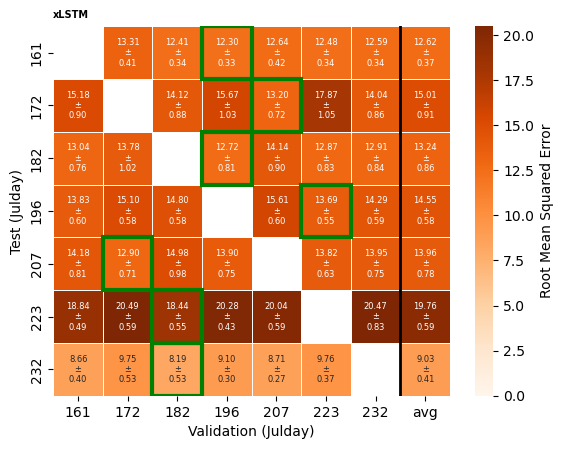

In [42]:
fig, ax = plt.subplots()

model, interval, metric = "xLSTM", 5, "RMSE"
compile_and_plot(run_paths, model, interval=interval, ax=ax, title=model, cache_path=f"{model}-average-{interval}-{metric}.npz", metric=metric);

In [48]:
import numpy as np
import pandas as pd
def load_cached_heatmap_results(cache_path: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Load mean/SE matrices previously saved with cache_heatmap_results()."""
    data = np.load(cache_path, allow_pickle=True)
    index = data["index"]
    columns = data["columns"]
    mean_mat = pd.DataFrame(data["mean"], index=index, columns=columns)
    se_mat = pd.DataFrame(data["se"], index=index, columns=columns)
    return mean_mat, se_mat

In [49]:
a,b = load_cached_heatmap_results("LSTM-0-5-RMSE.npz")

In [50]:
a

,161,172,182,196,207,223,232,avg
161,NaN,13.43655,12.73835,13.53010,13.26695,11.86340,12.85305,12.948067
172,13.75440,NaN,12.85200,13.91150,12.80770,17.71855,14.68860,14.288792
182,12.21860,12.93410,NaN,12.41315,13.48450,13.15925,12.44795,12.776258
196,16.56555,16.19785,15.73745,NaN,16.13205,15.38110,16.18775,16.033625
207,14.91785,14.90385,15.93165,15.14900,NaN,15.77440,15.43900,15.352625
223,16.25270,16.80810,16.82675,16.00685,16.76925,NaN,16.54795,16.535267
232,8.25160,8.38865,7.91330,8.13840,7.93415,7.54140,NaN,8.027917


In [51]:
b

,161,172,182,196,207,223,232,avg
161,NaN,0.426751,0.395685,0.409997,0.392347,0.332180,0.376490,0.390044
172,0.829072,NaN,0.792493,1.198887,0.901150,1.300808,1.248376,1.065782
182,0.976787,1.005182,NaN,0.938110,1.030842,0.914036,0.964037,0.972284
196,0.647300,0.642406,0.638244,NaN,0.653045,0.658461,0.635052,0.645803
207,0.799252,0.791446,0.908129,0.750651,NaN,0.794000,0.796356,0.808083
223,0.425991,0.419652,0.437102,0.463490,0.489962,NaN,0.432390,0.445436
232,0.364717,0.262070,0.280143,0.280939,0.338416,0.241280,NaN,0.297727
